# CA 2: Stock Prices Forecasting

This project aims to develop, evaluate, and compare autoregressive, gradient boosting, and neural networks algorithms on forecasting using stock market data, incorporating sentiment analysis from social media as exogenous data.The objective is to analyze the effectiveness of advance data analytics techniques in conjunction with Big Data processing.

The selected companies for the experiment are: AAPL, AMZN, NFLX, NVDIA, and TSLA.

The project is divided into two Jupyter notebooks.

Part 1:

Focuses on Big Data techniques, including the use of HDFS, MySQL, and NoSQL databases; exploratory data analysis; sentiment analysis; and big data streaming techniques utilizing the PySpark language.

Part 2:

Covers advanced data analytics, such as the development and application of autoregressive, gradient boosting, and neural network models; sentiment analysis; and the incorporation of an interactive dashboard.

The explanation video was uploaded into two different google drive accounts, just in case one of them has an error. 

# Part 1

## Libraries

In [14]:
#Spark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_date
from pyspark.sql.functions import lit, to_date
import pyspark.sql.functions as fn
from pyspark.sql.functions import desc
from pyspark.sql.functions import asc
from pyspark.sql.functions import round
from pyspark.sql.functions import when


# Plots
import matplotlib.pyplot as plt

#Check performance
import time

#sentiment analysis
from pyspark.sql.functions import pandas_udf
from pyspark.sql.types import StringType
from textblob import TextBlob
from pyspark.sql.types import DoubleType
from pyspark.sql.functions import udf
from pyspark.sql.types import FloatType

# Manipulation data
import pandas as pd
from datetime import datetime

#Reddit
import praw
#json
import json
#kafka
from kafka import KafkaProducer
import json

# statistics
from pyspark.mllib.linalg import Vectors
from pyspark.mllib.regression import LabeledPoint
from pyspark.mllib.stat import Statistics
from scipy import stats



## Stating Spark Session

In [4]:
spark = SparkSession.builder.appName('CA_2').getOrCreate()

25/04/28 20:36:49 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


## Load the stocktweet dataset from Hadoop

In [50]:
tweets =spark.read.csv('/CA_2/stock-tweet-and-price/stocktweet/stocktweet.csv',header=True,inferSchema=True)

In [51]:
tweets.show(5)

+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100001|01/01/2020|  AMZN|$AMZN Dow futures...|
|100002|01/01/2020|  TSLA|$TSLA Daddy's dri...|
|100003|01/01/2020|  AAPL|$AAPL We’ll been ...|
|100004|01/01/2020|  TSLA|$TSLA happy new y...|
|100005|01/01/2020|  TSLA|"$TSLA haha just ...|
+------+----------+------+--------------------+
only showing top 5 rows



# Exploratory Data Analysis

### Schema

In [7]:
tweets.printSchema()

root
 |-- id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- ticker: string (nullable = true)
 |-- tweet: string (nullable = true)



### Data types

In [8]:
tweets.dtypes

[('id', 'string'),
 ('date', 'string'),
 ('ticker', 'string'),
 ('tweet', 'string')]

### Summary Statistics

In [9]:
tweets.describe().show()

25/04/26 14:36:00 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+--------------------+--------------------+--------------------+--------------------+
|summary|                  id|                date|              ticker|               tweet|
+-------+--------------------+--------------------+--------------------+--------------------+
|  count|               11149|               10108|               10030|               10008|
|   mean|  104979.70625874825|               189.0|                null|                null|
| stddev|  3239.5707345331653|  103.23759005323593|                null|                null|
|    min|                 ...|                    | 116.50????? 😍🙏🏼"|        Amazon fresh|
|    max|             🧸gang"|it is different😂...|                 XOM|🚨🔥☆☆☆ $TSLA ☆☆☆...|
+-------+--------------------+--------------------+--------------------+--------------------+



### Analizing for Missing Values

In [10]:
tweets.filter(tweets['id'].isNull()).show()
tweets.filter(tweets['date'].isNull()).show()
tweets.filter(tweets['ticker'].isNull()).show()
tweets.filter(tweets['tweet'].isNull()).show()

+---+----+------+-----+
| id|date|ticker|tweet|
+---+----+------+-----+
+---+----+------+-----+

+--------------------+----+------+-----+
|                  id|date|ticker|tweet|
+--------------------+----+------+-----+
|Tesla shorts: OMG...|null|  null| null|
|              -Dory"|null|  null| null|
|Keep shorting ple...|null|  null| null|
|           👍💵💵💵"|null|  null| null|
|Don’t say wait u ...|null|  null| null|
|                 💵"|null|  null| null|
|             😂😂😂"|null|  null| null|
|                 😂"|null|  null| null|
|Literally everyth...|null|  null| null|
|Personally I'm ch...|null|  null| null|
|          💤 💤💤😴"|null|  null| null|
|put buyers eating...|null|  null| null|
|Weather forecasts...|null|  null| null|
|               Very"|null|  null| null|
|Just printing mon...|null|  null| null|
|                  🙈|null|  null| null|
|still more than d...|null|  null| null|
|Tomorrow I’m expe...|null|  null| null|
|Now going to $840...|null|  null| null|
|              

In [11]:
#Drop rows where any of the key columns are null
tweet= tweets.dropna(subset=["id", "date", "ticker", "tweet"])

In [12]:
tweet.show(5)

+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100001|01/01/2020|  AMZN|$AMZN Dow futures...|
|100002|01/01/2020|  TSLA|$TSLA Daddy's dri...|
|100003|01/01/2020|  AAPL|$AAPL We’ll been ...|
|100004|01/01/2020|  TSLA|$TSLA happy new y...|
|100005|01/01/2020|  TSLA|"$TSLA haha just ...|
+------+----------+------+--------------------+
only showing top 5 rows



### Displaying Bad rows ( rows with Null values)

In [35]:
bad_rows = tweets.filter(col("id").isNull() | col("date").isNull() | col("ticker").isNull() | col("tweet").isNull())
bad_rows.show()

+--------------------+--------------------+------+-----+
|                  id|                date|ticker|tweet|
+--------------------+--------------------+------+-----+
|Tesla shorts: OMG...|                null|  null| null|
|              -Dory"|                null|  null| null|
|Keep shorting ple...|                null|  null| null|
|           👍💵💵💵"|                null|  null| null|
|Don’t say wait u ...|                null|  null| null|
|                 💵"|                null|  null| null|
|             😂😂😂"|                null|  null| null|
|                 😂"|                null|  null| null|
|Literally everyth...|                null|  null| null|
|Personally I'm ch...|                null|  null| null|
|          💤 💤💤😴"|                null|  null| null|
|put buyers eating...|                null|  null| null|
|Weather forecasts...|                null|  null| null|
|               Very"|                null|  null| null|
|Just printing mon...|                null| 

### Filtering Tickers

For this proyect I analyzed 5 Companies: Apple (AAPL), Tesla (TSLA), Amazon (AMZN), Nvidia (NVDA), and Netflix (NFLX)

In [13]:
tweet.select("ticker").distinct().show()

+--------------------+
|              ticker|
+--------------------+
|                 TSM|
|                AAPL|
|      company buying|
|                 XOM|
| People that don'...|
|                 CCL|
|                 JPM|
|                 DIS|
|         Nissan LEAF|
|                TSLA|
|                  PG|
|                 MCD|
| plus lawsuits an...|
|                 AMT|
|                   V|
|                 PFE|
|                GOOG|
|                NFLX|
|                  FB|
|                 UNH|
+--------------------+
only showing top 20 rows



In [15]:
#filter to only 5 tickers
tickers = ["AAPL", "TSLA", "AMZN", "NVDA", "NFLX"]
tweet_t = tweet.filter(col("ticker").isin(tickers))

tweet_t.show(5)

+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100001|01/01/2020|  AMZN|$AMZN Dow futures...|
|100002|01/01/2020|  TSLA|$TSLA Daddy's dri...|
|100003|01/01/2020|  AAPL|$AAPL We’ll been ...|
|100004|01/01/2020|  TSLA|$TSLA happy new y...|
|100005|01/01/2020|  TSLA|"$TSLA haha just ...|
+------+----------+------+--------------------+
only showing top 5 rows



#### Tickers in the dataset

In [15]:
tweet_t.select("ticker").distinct().show()

+------+
|ticker|
+------+
|  AAPL|
|  TSLA|
|  NFLX|
|  AMZN|
|  NVDA|
+------+



#### Counting tweets by ticker

In [17]:
tweet_t.groupBy("ticker").count().orderBy("count", ascending=False).show()

+------+-----+
|ticker|count|
+------+-----+
|  TSLA| 4341|
|  AAPL| 1721|
|  AMZN|  407|
|  NFLX|  195|
|  NVDA|  119|
+------+-----+



### Tweet Distribution

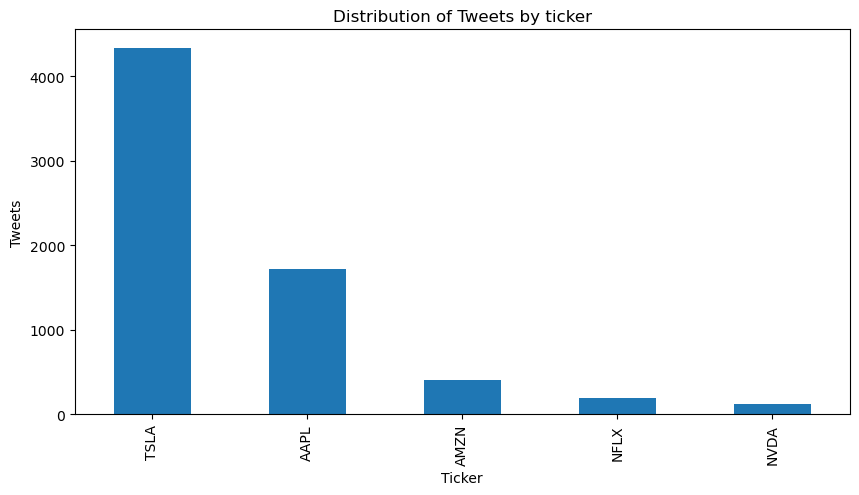

In [20]:
pandas_t = tweet_t.select("ticker").toPandas()
pandas_t["ticker"].value_counts().plot(kind="bar", figsize=(10,5))
plt.xlabel("Ticker")
plt.ylabel("Tweets")
plt.title("Distribution of Tweets by ticker")
plt.show()

### Creating a dataset with ONLY AAPL tweets

In [26]:
tweet_aapl = tweet.filter(col("ticker").isin('AAPL'))

tweet_aapl.show(5)

+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100003|01/01/2020|  AAPL|$AAPL We’ll been ...|
|100007|02/01/2020|  AAPL|$AAPL $300 calls ...|
|100008|02/01/2020|  AAPL|$AAPL Remember, i...|
|100009|02/01/2020|  AAPL|$AAPL called it, ...|
|100011|02/01/2020|  AAPL|Apple is taking t...|
+------+----------+------+--------------------+
only showing top 5 rows



### Creating a dataset with ONLY AMZN tweets

### Creating a dataset with ONLY TSLA tweets

In [28]:
tweet_tsla = tweet.filter(col("ticker").isin('TSLA'))

tweet_tsla.show(5)

+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100002|01/01/2020|  TSLA|$TSLA Daddy's dri...|
|100004|01/01/2020|  TSLA|$TSLA happy new y...|
|100005|01/01/2020|  TSLA|"$TSLA haha just ...|
|100006|01/01/2020|  TSLA|$TSLA NOBODY: Gas...|
|100019|03/01/2020|  TSLA|$TSLA  I must ris...|
+------+----------+------+--------------------+
only showing top 5 rows



### Creating a dataset with ONLY NVDA tweets

In [29]:
tweet_nvda = tweet.filter(col("ticker").isin('NVDA'))

tweet_nvda.show(5)

+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100014|03/01/2020|  NVDA|$NVDA This should...|
|100109|10/01/2020|  NVDA|$NVDA i love when...|
|100678|11/02/2020|  NVDA|$NVDA thoughts op...|
|100746|13/02/2020|  NVDA|$NVDA Easy money ...|
|100809|19/02/2020|  NVDA|$NVDA 👏👏💸💸💸👏👏|
+------+----------+------+--------------------+
only showing top 5 rows



### Creating a dataset with ONLY NFLX tweets

In [30]:
tweet_nflx = tweet.filter(col("ticker").isin('NFLX'))

tweet_nflx.show(5)

+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100032|06/01/2020|  NFLX|$NFLX 🔥🔥🔥✈️ 33...|
|100118|10/01/2020|  NFLX|$NFLX Morningstar...|
|100237|18/01/2020|  NFLX|$NFLX 💵 booked a...|
|100254|22/01/2020|  NFLX|$NFLX love when t...|
|100278|22/01/2020|  NFLX|$NFLX  sooo if 36...|
+------+----------+------+--------------------+
only showing top 5 rows



## Load stock Dataset from Hadoop

In [50]:
aapl=spark.read.csv('/CA_2/stock-tweet-and-price/stockprice/AAPL.csv',header=True,inferSchema=True)


In [51]:
aapl.show(5)

+----------+-----------------+-----------------+-----------------+-----------------+-----------------+---------+
|      Date|             Open|             High|              Low|            Close|        Adj Close|   Volume|
+----------+-----------------+-----------------+-----------------+-----------------+-----------------+---------+
|2019-12-31|72.48249816894531|73.41999816894531|72.37999725341797| 73.4124984741211|71.52082061767578|100805600|
|2020-01-02|74.05999755859375| 75.1500015258789|73.79750061035156| 75.0875015258789|73.15264892578125|135480400|
|2020-01-03| 74.2874984741211| 75.1449966430664|           74.125|74.35749816894531|72.44145965576172|146322800|
|2020-01-06|73.44750213623047|74.98999786376953|          73.1875|74.94999694824219| 73.0186767578125|118387200|
|2020-01-07|74.95999908447266| 75.2249984741211|74.37000274658203|74.59750366210938|72.67527770996094|108872000|
+----------+-----------------+-----------------+-----------------+-----------------+------------

### Creating a Dataset with AAPL, TSLA, AMZN, NVDA, NFLX Tickers concatenated

In [21]:
# List of tickers you have data for
tickers = ["AAPL", "TSLA", "AMZN", "NVDA", "NFLX"]


stock_dfs = []
for ticker in tickers:
    df = spark.read.csv(f"/CA_2/stock-tweet-and-price/stockprice/{ticker}.csv", header=True, inferSchema=True)
    df = df.withColumn("ticker", lit(ticker))
   # df = df.withColumn("date", to_date("Date", "dd/MM/yyyy")).drop("Date")  # Normalize column
    stock_dfs.append(df)
    
# Union all into one large stock DataFrame
stock = stock_dfs[0]
for df in stock_dfs[1:]:
    stock = stock.unionByName(df)

stock.show(5)

+----------+-----------------+-----------------+-----------------+-----------------+-----------------+---------+------+
|      Date|             Open|             High|              Low|            Close|        Adj Close|   Volume|ticker|
+----------+-----------------+-----------------+-----------------+-----------------+-----------------+---------+------+
|2019-12-31|72.48249816894531|73.41999816894531|72.37999725341797| 73.4124984741211|71.52082061767578|100805600|  AAPL|
|2020-01-02|74.05999755859375| 75.1500015258789|73.79750061035156| 75.0875015258789|73.15264892578125|135480400|  AAPL|
|2020-01-03| 74.2874984741211| 75.1449966430664|           74.125|74.35749816894531|72.44145965576172|146322800|  AAPL|
|2020-01-06|73.44750213623047|74.98999786376953|          73.1875|74.94999694824219| 73.0186767578125|118387200|  AAPL|
|2020-01-07|74.95999908447266| 75.2249984741211|74.37000274658203|74.59750366210938|72.67527770996094|108872000|  AAPL|
+----------+-----------------+----------

## Exploratory Data Analysis

#### Check Schema

In [25]:
stock.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Adj Close: double (nullable = true)
 |-- Volume: integer (nullable = true)
 |-- ticker: string (nullable = false)



#### Data Types

In [28]:
stock.dtypes

[('Date', 'date'),
 ('Open', 'double'),
 ('High', 'double'),
 ('Low', 'double'),
 ('Close', 'double'),
 ('Adj Close', 'double'),
 ('Volume', 'int'),
 ('ticker', 'string')]

#### Summary Statistics

In [126]:
stock.describe(["open", "high", "low", "close", "volume"]).show()


25/04/29 00:17:41 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+------------------+------------------+------------------+--------------------+
|summary|              open|              high|               low|             close|              volume|
+-------+------------------+------------------+------------------+------------------+--------------------+
|  count|              1270|              1270|              1270|              1270|                1270|
|   mean|173.90595884848767|177.06954532082625|170.76302346807765|174.12513132470798|1.0726406023622048E8|
| stddev| 143.5697145217562|146.05253765975786|141.12454749474912|143.75158135683802|1.0156801031269239E8|
|    min|24.979999542236328| 26.99066734313965|23.367332458496094| 24.08133316040039|             1144000|
|    max|   567.97998046875| 575.3699951171875|             541.0| 556.5499877929688|           914082000|
+-------+------------------+------------------+------------------+------------------+--------------------+



### Analyzing for missing values

In [32]:
stock.filter(stock["Date"].isNull()).show()
stock.filter(stock["Open"].isNull()).show()
stock.filter(stock["High"].isNull()).show()
stock.filter(stock["Low"].isNull()).show()
stock.filter(stock["Close"].isNull()).show()
stock.filter(stock["Adj Close"].isNull()).show()
stock.filter(stock["Volume"].isNull()).show()
stock.filter(stock["ticker"].isNull()).show()

+----+----+----+---+-----+---------+------+------+
|Date|Open|High|Low|Close|Adj Close|Volume|ticker|
+----+----+----+---+-----+---------+------+------+
+----+----+----+---+-----+---------+------+------+

+----+----+----+---+-----+---------+------+------+
|Date|Open|High|Low|Close|Adj Close|Volume|ticker|
+----+----+----+---+-----+---------+------+------+
+----+----+----+---+-----+---------+------+------+

+----+----+----+---+-----+---------+------+------+
|Date|Open|High|Low|Close|Adj Close|Volume|ticker|
+----+----+----+---+-----+---------+------+------+
+----+----+----+---+-----+---------+------+------+

+----+----+----+---+-----+---------+------+------+
|Date|Open|High|Low|Close|Adj Close|Volume|ticker|
+----+----+----+---+-----+---------+------+------+
+----+----+----+---+-----+---------+------+------+

+----+----+----+---+-----+---------+------+------+
|Date|Open|High|Low|Close|Adj Close|Volume|ticker|
+----+----+----+---+-----+---------+------+------+
+----+----+----+---+-----+-

No missing values

#### tickers

In [33]:
stock.select("ticker").distinct().show()

+------+
|ticker|
+------+
|  AAPL|
|  TSLA|
|  AMZN|
|  NVDA|
|  NFLX|
+------+



#### Value count for ticker

In [34]:
stock.groupBy("ticker").count().orderBy("count", ascending=False).show()

+------+-----+
|ticker|count|
+------+-----+
|  AAPL|  254|
|  TSLA|  254|
|  AMZN|  254|
|  NVDA|  254|
|  NFLX|  254|
+------+-----+



### Value count Distribution

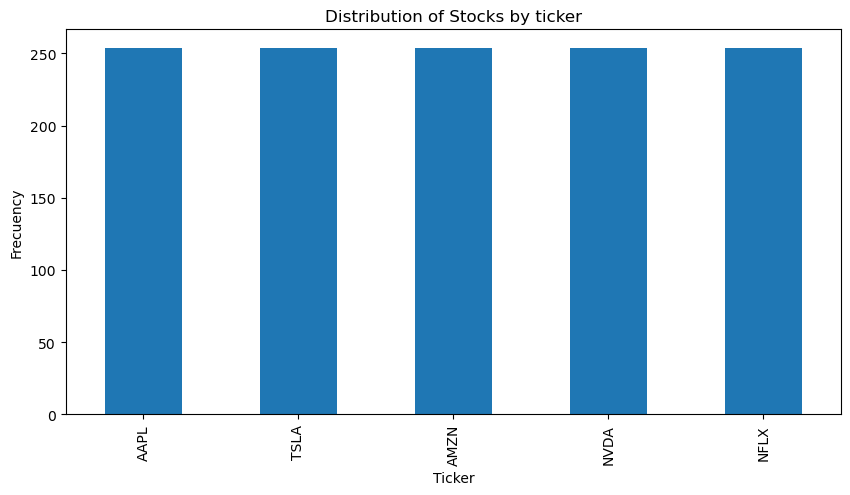

In [125]:
pandas_s = stock.select("ticker").toPandas()
pandas_s["ticker"].value_counts().plot(kind="bar", figsize=(10,5))
plt.xlabel("Ticker")
plt.ylabel("Frecuency")
plt.title("Distribution of Stocks by ticker")
plt.show()

### Volume Distribution

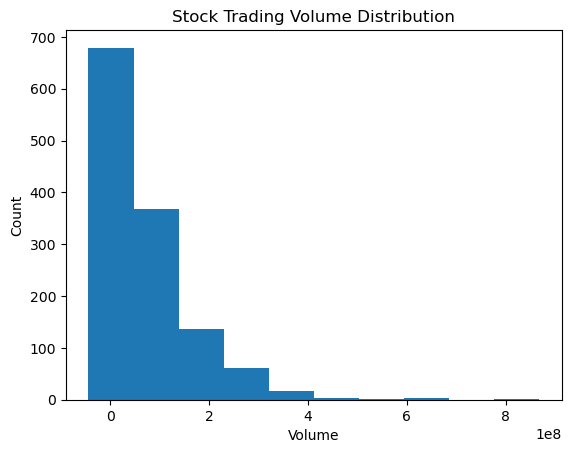

In [130]:
hist_data = stock.select("volume").rdd.flatMap(lambda x: x).histogram(10)

bin_edges, counts = hist_data
plt.bar(bin_edges[:-1], counts, width=[bin_edges[i+1] - bin_edges[i] for i in range(len(bin_edges)-1)])
plt.xlabel("Volume")
plt.ylabel("Count")
plt.title("Stock Trading Volume Distribution")
plt.show()


### Distribution of returns: ((close - open) / open) and Volatility : ((high - low) / open)

In [131]:
# Calculate daily retung and daily volatility
df = stock.withColumn("daily_return", (col("close") - col("open")) / col("open")) \
       .withColumn("daily_volatility", (col("high") - col("low")) / col("open"))

df.select("date", "ticker", "open", "close", "high", "low", "daily_return", "daily_volatility").show(5)


+----------+------+-----------------+-----------------+-----------------+-----------------+--------------------+--------------------+
|      date|ticker|             open|            close|             high|              low|        daily_return|    daily_volatility|
+----------+------+-----------------+-----------------+-----------------+-----------------+--------------------+--------------------+
|2019-12-31|  AAPL|72.48249816894531| 73.4124984741211|73.41999816894531|72.37999725341797|0.012830687802841682|0.014348303960264519|
|2020-01-02|  AAPL|74.05999755859375| 75.0875015258789| 75.1500015258789|73.79750061035156|0.013873940064232787| 0.01826223278575308|
|2020-01-03|  AAPL| 74.2874984741211|74.35749816894531| 75.1449966430664|           74.125|9.422809525428286E-4|0.013730394265755681|
|2020-01-06|  AAPL|73.44750213623047|74.94999694824219|74.98999786376953|          73.1875| 0.02045671763247837|0.024541309252781085|
|2020-01-07|  AAPL|74.95999908447266|74.59750366210938| 75.224

In [132]:
# Summary statistics for returns and volatility
df.select("daily_return", "daily_volatility").describe().show()


+-------+--------------------+--------------------+
|summary|        daily_return|    daily_volatility|
+-------+--------------------+--------------------+
|  count|                1270|                1270|
|   mean|0.001764716798872...|0.038560620199774735|
| stddev| 0.02695365208954939|0.026260859443076278|
|    min|-0.10757232435825766| 0.00809986989323323|
|    max| 0.15780255905040316|   0.249639718787476|
+-------+--------------------+--------------------+



In [133]:
# Returns histogram
return_hist = df.select("daily_return").rdd.flatMap(lambda x: x).histogram(50)

# Volatility histogram
volatility_hist = df.select("daily_volatility").rdd.flatMap(lambda x: x).histogram(50)


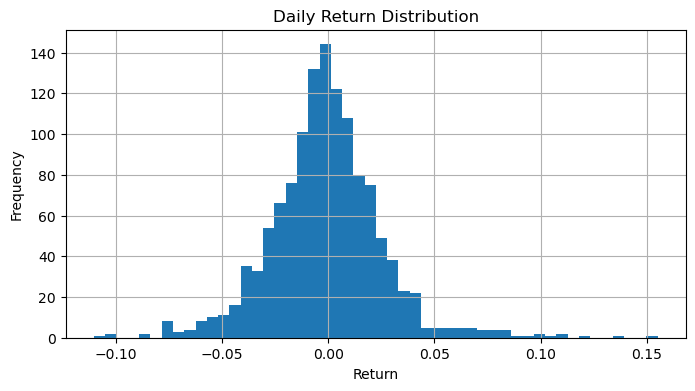

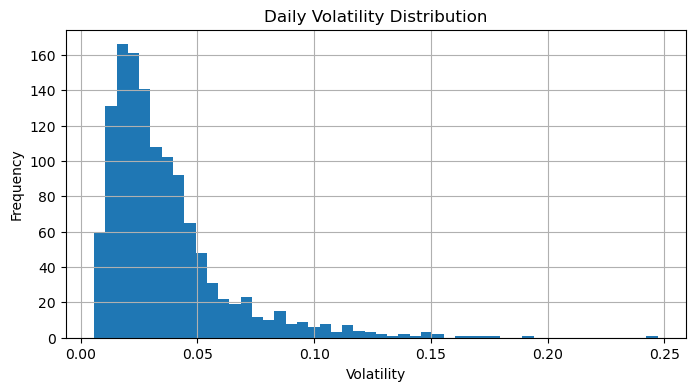

In [135]:
import matplotlib.pyplot as plt

# Plot returns
bin_edges_return, counts_return = return_hist
plt.figure(figsize=(8, 4))
plt.bar(bin_edges_return[:-1], counts_return, width=[bin_edges_return[i+1] - bin_edges_return[i] for i in range(len(bin_edges_return)-1)])
plt.title("Daily Return Distribution")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Plot volatility
bin_edges_vol, counts_vol = volatility_hist
plt.figure(figsize=(8, 4))
plt.bar(bin_edges_vol[:-1], counts_vol, width=[bin_edges_vol[i+1] - bin_edges_vol[i] for i in range(len(bin_edges_vol)-1)])
plt.title("Daily Volatility Distribution")
plt.xlabel("Volatility")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


### Top 5 gainer stocks

In [136]:
# Top 5 biggest daily gains
top_gainers = df.orderBy(desc("daily_return")).select("date", "ticker", "open", "close", "daily_return").limit(5)
top_gainers.show(truncate=False)


+----------+------+------------------+------------------+-------------------+
|date      |ticker|open              |close             |daily_return       |
+----------+------+------------------+------------------+-------------------+
|2020-02-03|TSLA  |44.91266632080078 |52.0              |0.15780255905040316|
|2020-03-19|TSLA  |24.979999542236328|28.50933265686035 |0.14128635625699698|
|2020-08-31|TSLA  |148.20333862304688|166.10667419433594|0.12080251185721225|
|2020-02-28|NVDA  |60.6150016784668  |67.51750183105469 |0.11387445288218102|
|2020-08-26|NFLX  |492.5             |547.530029296875  |0.11173610009517766|
+----------+------+------------------+------------------+-------------------+



### Top 5 Loser Stocks

In [138]:
# Top 5 biggest daily losses
top_crashers = df.orderBy(asc("daily_return")).select("date", "ticker", "open", "close", "daily_return").limit(5)
top_crashers.show(truncate=False)

+----------+------+------------------+------------------+--------------------+
|date      |ticker|open              |close             |daily_return        |
+----------+------+------------------+------------------+--------------------+
|2020-02-05|TSLA  |54.88399887084961 |48.97999954223633 |-0.10757232435825766|
|2020-07-23|TSLA  |111.93000030517578|100.87133026123047|-0.09879987504506373|
|2020-07-13|TSLA  |110.5999984741211 |99.80400085449219 |-0.09761299971586368|
|2020-04-30|TSLA  |57.01266860961914 |52.12533187866211 |-0.08572369703340711|
|2020-03-13|TSLA  |39.66666793823242 |36.44133377075195 |-0.08131094279214096|
+----------+------+------------------+------------------+--------------------+



## Screenshot of Hadoop

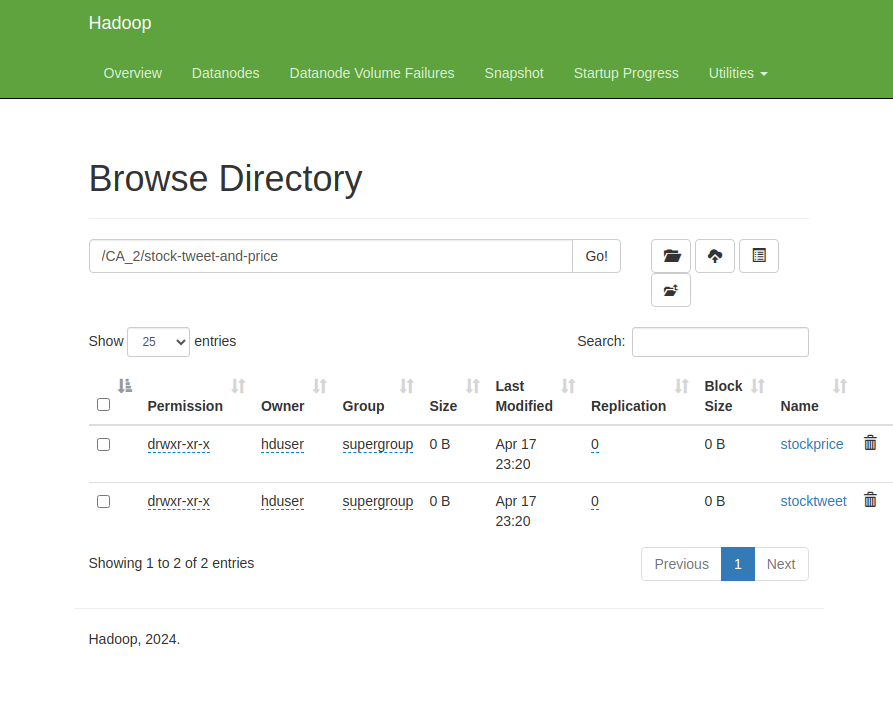

## Save datasets into Cassandra

### Saving tweets dataset

In [49]:
# initializing spark session with cassandra conector
spark = SparkSession.builder \
    .appName("LoadToCassandra") \
    .enableHiveSupport() \
    .config("spark.cassandra.connection.host", "127.0.0.1") \
    .config("spark.jars.packages", "com.datastax.spark:spark-cassandra-connector_2.12:3.1.0") \
    .getOrCreate()

25/04/28 21:31:31 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [15]:
# loading the tweets from hadoop
tweets_df = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv("/CA_2/stock-tweet-and-price/stocktweet/stocktweet.csv")

In [16]:
tweets_df.show(5)

+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100001|01/01/2020|  AMZN|$AMZN Dow futures...|
|100002|01/01/2020|  TSLA|$TSLA Daddy's dri...|
|100003|01/01/2020|  AAPL|$AAPL We’ll been ...|
|100004|01/01/2020|  TSLA|$TSLA happy new y...|
|100005|01/01/2020|  TSLA|"$TSLA haha just ...|
+------+----------+------+--------------------+
only showing top 5 rows



In [14]:
tweets_df \
    .select(
        col("id").cast("string"),
        col("date").cast("timestamp"),
        col("ticker").cast("string"),
        col("tweet"),
    ) \
    .write \
    .format("org.apache.spark.sql.cassandra") \
    .mode("append") \
    .options(table="tweets", keyspace="stockks") \
    .save()

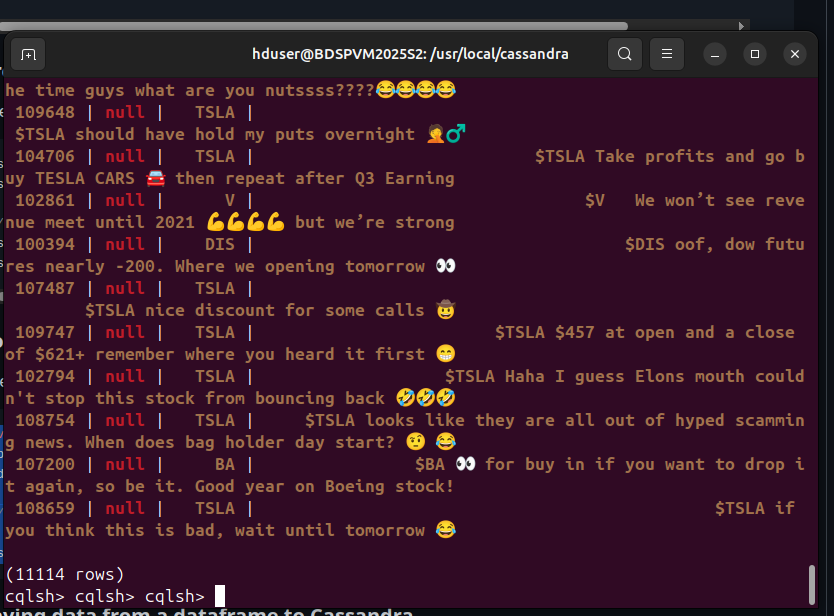

### Load Tweets from Cassandra

In [6]:
tweet_cassandra=spark.read.format("org.apache.spark.sql.cassandra").options(table="tweets", keyspace="stockks").load()
tweet_cassandra.show(5)

+--------------------+----+------+--------------------+
|                  id|date|ticker|               tweet|
+--------------------+----+------+--------------------+
|              106023|null|  TSLA|$TSLA can’t wait ...|
|              106369|null|  AAPL|$AAPL Apple annou...|
|DO NOT BE LIKE NO...|null|  null|                null|
|              102395|null|  AAPL|$AAPL who says th...|
|Holding my 500 at...|null|  null|                null|
+--------------------+----+------+--------------------+
only showing top 5 rows



### Saving stock dataset

In [19]:
stock.show(5)

+----------+-----------------+-----------------+-----------------+-----------------+-----------------+---------+------+
|      Date|             Open|             High|              Low|            Close|        Adj Close|   Volume|ticker|
+----------+-----------------+-----------------+-----------------+-----------------+-----------------+---------+------+
|2019-12-31|72.48249816894531|73.41999816894531|72.37999725341797| 73.4124984741211|71.52082061767578|100805600|  AAPL|
|2020-01-02|74.05999755859375| 75.1500015258789|73.79750061035156| 75.0875015258789|73.15264892578125|135480400|  AAPL|
|2020-01-03| 74.2874984741211| 75.1449966430664|           74.125|74.35749816894531|72.44145965576172|146322800|  AAPL|
|2020-01-06|73.44750213623047|74.98999786376953|          73.1875|74.94999694824219| 73.0186767578125|118387200|  AAPL|
|2020-01-07|74.95999908447266| 75.2249984741211|74.37000274658203|74.59750366210938|72.67527770996094|108872000|  AAPL|
+----------+-----------------+----------

In [24]:
stock \
    .select(
        col("ticker"),
        col("date"),
        col("open"),
        col("high"),
        col("low"),
        col("close"),
        col("volume")
    ) \
    .write \
    .format("org.apache.spark.sql.cassandra") \
    .mode("append") \
    .options(table="tickers", keyspace="stockks") \
    .save()

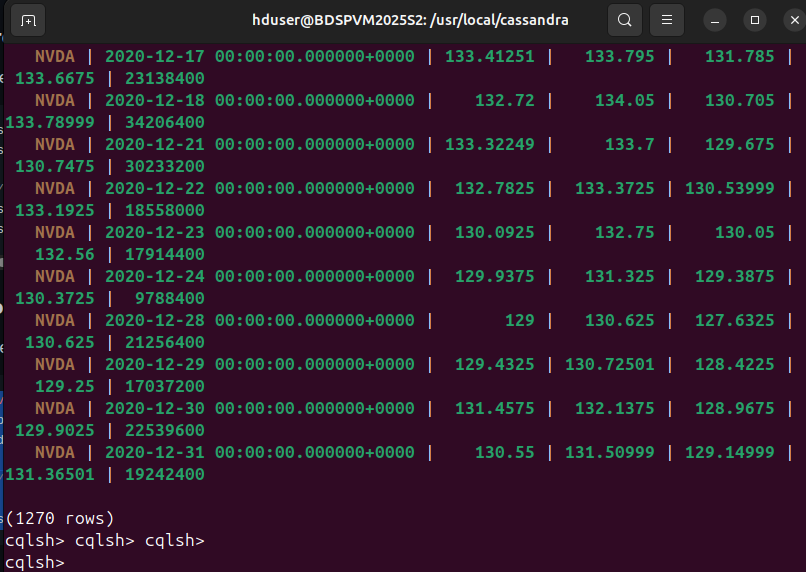

### Load Stocks from Cassandra

In [7]:
stocks_cassandra=spark.read.format("org.apache.spark.sql.cassandra").options(table="tickers", keyspace="stockks").load()
stocks_cassandra.show(5)

+------+-------------------+------------------+------------------+------------------+------------------+--------+
|ticker|               date|             close|              high|               low|              open|  volume|
+------+-------------------+------------------+------------------+------------------+------------------+--------+
|  NVDA|2019-12-31 00:00:00| 58.82500076293945| 58.91999816894531|57.532501220703125|57.724998474121094|23100400|
|  NVDA|2020-01-02 00:00:00|59.977500915527344|59.977500915527344| 59.18000030517578|           59.6875|23753600|
|  NVDA|2020-01-03 00:00:00| 59.01750183105469| 59.45750045776367|58.525001525878906|58.775001525878906|20538400|
|  NVDA|2020-01-06 00:00:00| 59.26499938964844|59.317501068115234|57.817501068115234| 58.08000183105469|26263600|
|  NVDA|2020-01-07 00:00:00| 59.98249816894531|60.442501068115234| 59.09749984741211| 59.54999923706055|31485600|
+------+-------------------+------------------+------------------+------------------+---

### Screenshot of tables in Cassandra

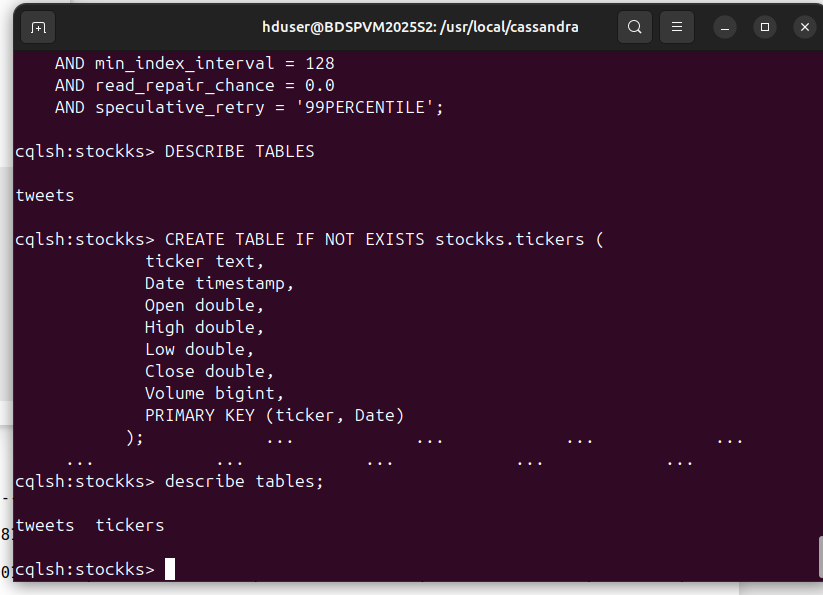

## Load Datasets into Spark SQL

In [9]:
sc.master

'local[*]'

In [52]:
#initialize SparkSession
spark = SparkSession.builder \
    .appName("SaveDatasetsToSparkSQL") \
    .enableHiveSupport() \
    .getOrCreate()


25/04/28 21:52:32 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


#### Create Database stocks

In [13]:
# Create database
spark.sql("CREATE DATABASE IF NOT EXISTS stocks")
spark.sql("USE stocks")

DataFrame[]

#### Load tweets in tweets table

In [17]:
# save tweets to Spark SQL table
tweets_df.write \
    .mode("overwrite") \
    .format("parquet") \
    .saveAsTable("tweets")

### Load stock into ticker table

In [22]:
# load stocks in Spark sql table
stock.write \
    .mode("overwrite") \
    .format("parquet") \
    .saveAsTable("ticker")

#### Display tables in Spark SQL

In [23]:
# Show all tables in the current database
spark.sql("SHOW TABLES").show()

+---------+---------+-----------+
|namespace|tableName|isTemporary|
+---------+---------+-----------+
|   stocks|   ticker|      false|
|   stocks|   tweets|      false|
+---------+---------+-----------+



### tweets Schema

In [20]:
# Describe schema of tweets table
spark.sql("DESCRIBE tweets").show()

+--------+---------+-------+
|col_name|data_type|comment|
+--------+---------+-------+
|      id|   string|   null|
|    date|   string|   null|
|  ticker|   string|   null|
|   tweet|   string|   null|
+--------+---------+-------+



#### Display tweets

In [24]:
# Execute SQL Query and return the data
spark.sql("select * from tweets").show(5)

+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100001|01/01/2020|  AMZN|$AMZN Dow futures...|
|100002|01/01/2020|  TSLA|$TSLA Daddy's dri...|
|100003|01/01/2020|  AAPL|$AAPL We’ll been ...|
|100004|01/01/2020|  TSLA|$TSLA happy new y...|
|100005|01/01/2020|  TSLA|"$TSLA haha just ...|
+------+----------+------+--------------------+
only showing top 5 rows



### ticker Schema

In [85]:
# Describe schema of tweets table
spark.sql("DESCRIBE ticker").show()

+---------+---------+-------+
| col_name|data_type|comment|
+---------+---------+-------+
|     Date|     date|   null|
|     Open|   double|   null|
|     High|   double|   null|
|      Low|   double|   null|
|    Close|   double|   null|
|Adj Close|   double|   null|
|   Volume|      int|   null|
|   ticker|   string|   null|
+---------+---------+-------+



### Display Stocks 

In [25]:
# Execute SQL Query and return the data
spark.sql("select * from ticker").show(5)

+----------+------------------+------------------+------------------+------------------+------------------+---------+------+
|      Date|              Open|              High|               Low|             Close|         Adj Close|   Volume|ticker|
+----------+------------------+------------------+------------------+------------------+------------------+---------+------+
|2019-12-31|              27.0|28.086000442504883| 26.80533218383789|  27.8886661529541|  27.8886661529541|154285500|  TSLA|
|2020-01-02|28.299999237060547|28.713333129882812| 28.11400032043457| 28.68400001525879| 28.68400001525879|142981500|  TSLA|
|2020-01-03|29.366666793823242|30.266666412353516|29.128000259399414|29.534000396728516|29.534000396728516|266677500|  TSLA|
|2020-01-06|29.364667892456055|30.104000091552734|29.333332061767578|  30.1026668548584|  30.1026668548584|151995000|  TSLA|
|2020-01-07|30.760000228881836|31.441999435424805|30.224000930786133|31.270666122436523|31.270666122436523|268231500|  TSLA|


#### Checking Schema

In [23]:
#schema
spark.table("tweets").printSchema()

root
 |-- id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- ticker: string (nullable = true)
 |-- tweet: string (nullable = true)



#### count of tweets

In [76]:
tweet_t.agg(
    fn.count('id').alias('count'),
    fn.countDistinct('id').alias('distinct')
).show()

+-----+--------+
|count|distinct|
+-----+--------+
| 6783|    6783|
+-----+--------+



### Missing values in tweet

In [79]:
tweet_t.agg(*[
    (1 - (fn.count(c) / fn.count('*'))).alias(c + '_missing')
    for c in tweet_t.columns
]).show()

+----------+------------+--------------+-------------+
|id_missing|date_missing|ticker_missing|tweet_missing|
+----------+------------+--------------+-------------+
|       0.0|         0.0|           0.0|          0.0|
+----------+------------+--------------+-------------+



### Missing values in stock

In [96]:
stock.agg(*[
    (1 - (fn.count(c) / fn.count('*'))).alias(c + '_missing')
    for c in stock.columns
]).show()

+------------+------------+------------+-----------+-------------+-----------------+--------------+--------------+
|Date_missing|Open_missing|High_missing|Low_missing|Close_missing|Adj Close_missing|Volume_missing|ticker_missing|
+------------+------------+------------+-----------+-------------+-----------------+--------------+--------------+
|         0.0|         0.0|         0.0|        0.0|          0.0|              0.0|           0.0|           0.0|
+------------+------------+------------+-----------+-------------+-----------------+--------------+--------------+



### Saving the new datasets into Hadoop

In [60]:
# tweets with tickers = ["AAPL", "TSLA", "AMZN", "NVDA", "NFLX"]
tweet_t.coalesce(1) \
  .write \
  .option("header", True) \
  .mode("overwrite") \
  .csv("/CA_2/tweets_csv")

In [61]:
# stocks about tickers = ["AAPL", "TSLA", "AMZN", "NVDA", "NFLX"]
stock.coalesce(1) \
  .write \
  .option("header", True) \
  .mode("overwrite") \
  .csv("/CA_2/stock_csv")

In [43]:
# AAPL tweets
tweet_aapl.coalesce(1) \
  .write \
  .option("header", True) \
  .mode("overwrite") \
  .csv("/CA_2/tweet_appl")

In [44]:
# TSLA tweets
tweet_tsla.coalesce(1) \
  .write \
  .option("header", True) \
  .mode("overwrite") \
  .csv("/CA_2/tweet_tsla")

In [47]:
# AMZN tweets
tweet_amzn.coalesce(1) \
  .write \
  .option("header", True) \
  .mode("overwrite") \
  .csv("/CA_2/tweet_amzn")

In [48]:
# NVDA tweets
tweet_nvda.coalesce(1) \
  .write \
  .option("header", True) \
  .mode("overwrite") \
  .csv("/CA_2/tweet_nvda")

In [49]:
# NFLX tweets
tweet_nflx.coalesce(1) \
  .write \
  .option("header", True) \
  .mode("overwrite") \
  .csv("/CA_2/tweet_nflx")

## Hdoop Screenshot

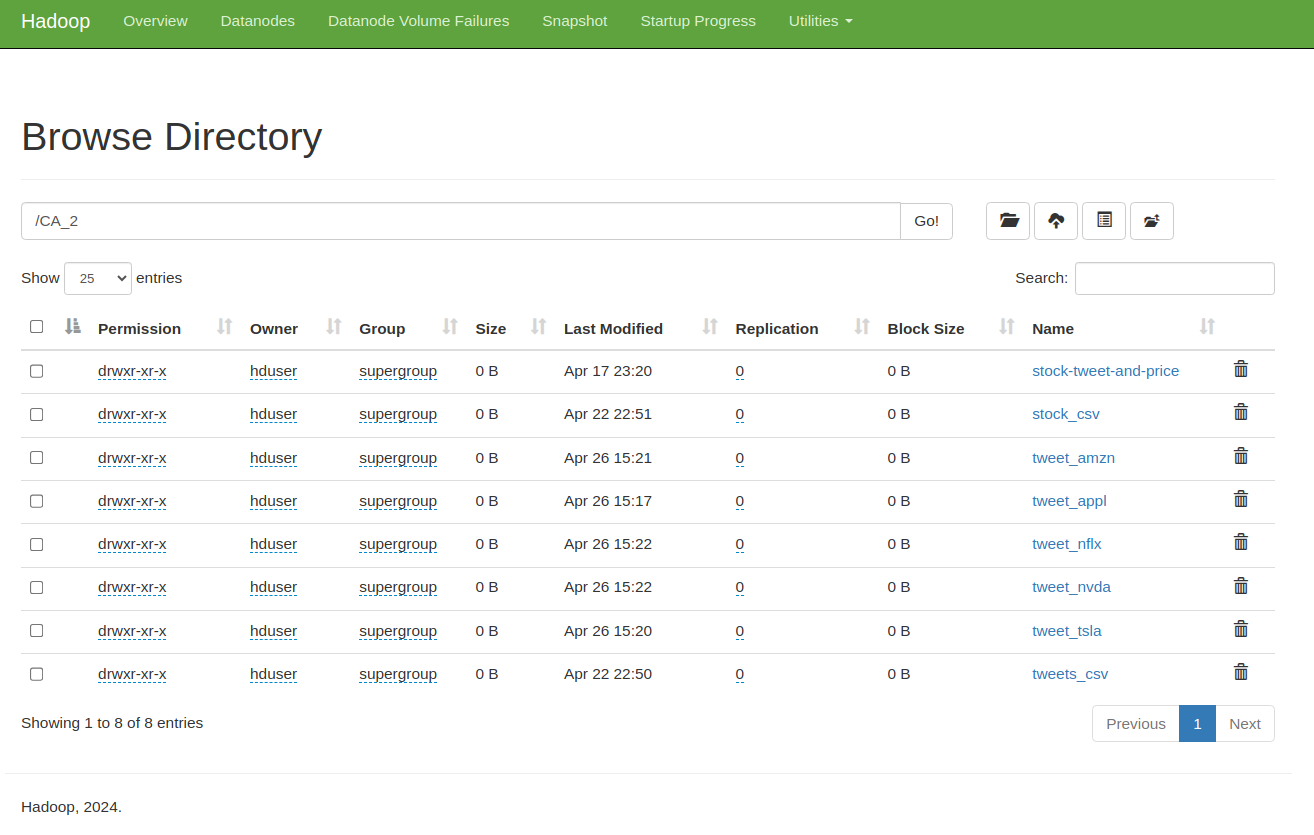

### Loading new tweets dataset from Hadoop

In [21]:
tweets_new =spark.read.csv('/CA_2/tweets_csv/part-00000-d5d9949d-a497-42b0-bfc2-3d4f2ceec208-c000.csv',header=True,inferSchema=True)

In [52]:
tweets_new.show(5)

+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100001|01/01/2020|  AMZN|$AMZN Dow futures...|
|100002|01/01/2020|  TSLA|$TSLA Daddy's dri...|
|100003|01/01/2020|  AAPL|$AAPL We’ll been ...|
|100004|01/01/2020|  TSLA|$TSLA happy new y...|
|100005|01/01/2020|  TSLA|"$TSLA haha just ...|
+------+----------+------+--------------------+
only showing top 5 rows



### Loading Stocks dataset from Hadoop

In [54]:
stock_new =spark.read.csv('/CA_2/stock_csv/part-00000-669b3b74-6d3c-469d-a9fa-a84cef0b762c-c000.csv',header=True,inferSchema=True)

In [58]:
stock_new.show(5)

+----------+-----------------+-----------------+-----------------+-----------------+-----------------+---------+------+
|      Date|             Open|             High|              Low|            Close|        Adj Close|   Volume|ticker|
+----------+-----------------+-----------------+-----------------+-----------------+-----------------+---------+------+
|2019-12-31|72.48249816894531|73.41999816894531|72.37999725341797| 73.4124984741211|71.52082061767578|100805600|  AAPL|
|2020-01-02|74.05999755859375| 75.1500015258789|73.79750061035156| 75.0875015258789|73.15264892578125|135480400|  AAPL|
|2020-01-03| 74.2874984741211| 75.1449966430664|           74.125|74.35749816894531|72.44145965576172|146322800|  AAPL|
|2020-01-06|73.44750213623047|74.98999786376953|          73.1875|74.94999694824219| 73.0186767578125|118387200|  AAPL|
|2020-01-07|74.95999908447266| 75.2249984741211|74.37000274658203|74.59750366210938|72.67527770996094|108872000|  AAPL|
+----------+-----------------+----------

## Comparison MySQL vs MongoDB Utilizing Workloads

In [45]:
with open('workloada_mongodb.txt', 'r') as file:
    content = file.read()
    print(content)

mongo client connection created with mongodb://localhost:27017/ycsb?w=1
[OVERALL], RunTime(ms), 1833
[OVERALL], Throughput(ops/sec), 1091.1074740861975
[TOTAL_GCS_PS_Scavenge], Count, 1
[TOTAL_GC_TIME_PS_Scavenge], Time(ms), 36
[TOTAL_GC_TIME_%_PS_Scavenge], Time(%), 1.9639934533551555
[TOTAL_GCS_PS_MarkSweep], Count, 0
[TOTAL_GC_TIME_PS_MarkSweep], Time(ms), 0
[TOTAL_GC_TIME_%_PS_MarkSweep], Time(%), 0.0
[TOTAL_GCs], Count, 1
[TOTAL_GC_TIME], Time(ms), 36
[TOTAL_GC_TIME_%], Time(%), 1.9639934533551555
[READ], Operations, 975
[READ], AverageLatency(us), 728.0769230769231
[READ], MinLatency(us), 295
[READ], MaxLatency(us), 57503
[READ], 95thPercentileLatency(us), 1030
[READ], 99thPercentileLatency(us), 1549
[READ], Return=OK, 975
[CLEANUP], Operations, 1
[CLEANUP], AverageLatency(us), 2071.0
[CLEANUP], MinLatency(us), 2070
[CLEANUP], MaxLatency(us), 2071
[CLEANUP], 95thPercentileLatency(us), 2071
[CLEANUP], 99thPercentileLatency(us), 2071
[UPDATE], Operations, 1025
[UPDATE], AverageLate

### Screenshot of terminal (workloada mongodb)

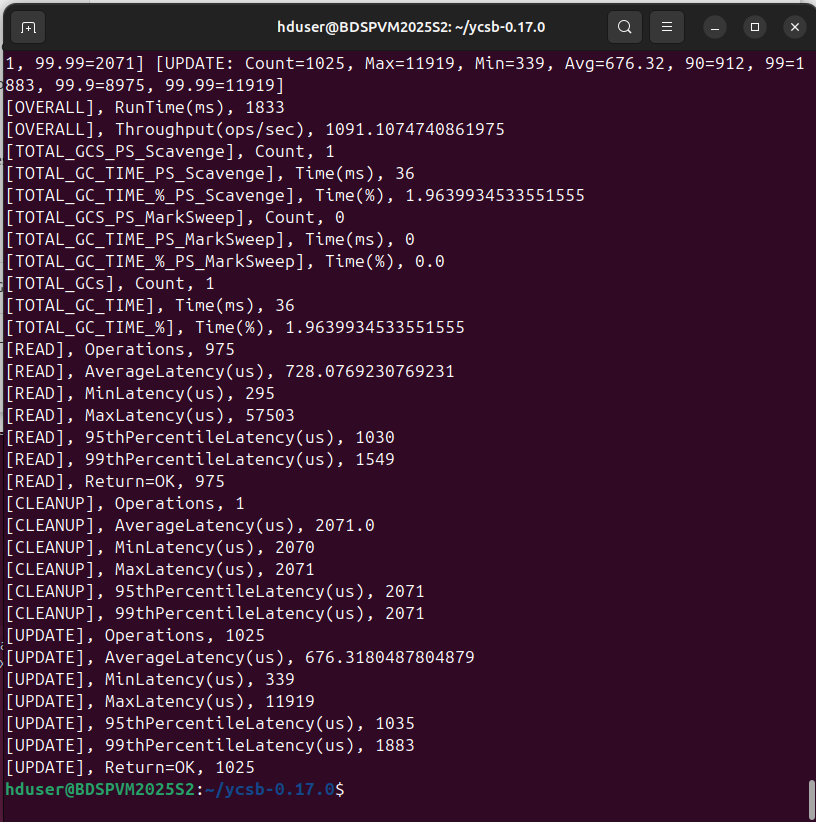

#### MySQL vs MongoDB comparison Plot

In [ ]:
# Set your directory and files
workloads = ['workloada', 'workloadb', 'workloadc']
databases = ['mongodb', 'mysql']
metrics_to_extract = {'[OVERALL], RunTime(ms)': 'RunTime(ms)'}

# Store extracted results
results = {workload: {db: {} for db in databases} for workload in workloads}


In [ ]:
# Function to parse a single file
def parse_file(filepath):
    data = {}
    with open(filepath, 'r') as file:
        for line in file:
            for key, label in metrics_to_extract.items():
                if key in line:
                    try:
                        value = float(line.strip().split(",")[-1])
                        data[label] = value
                    except:
                        pass
    return data


In [ ]:
# Parse all files
for workload in workloads:
    for db in databases:
        filename = f'{workload}_{db}.txt'
        if os.path.exists(filename):
            results[workload][db] = parse_file(filename)
        else:
            print(f"File not found: {filename}")

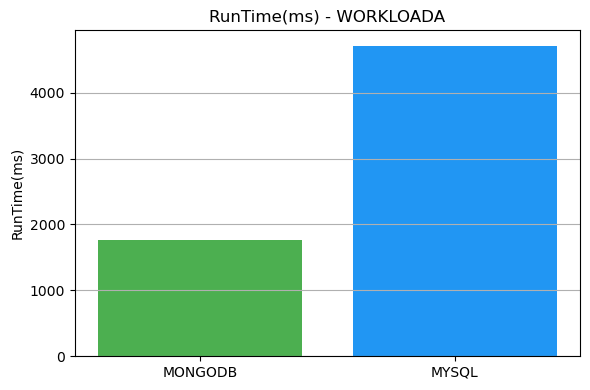

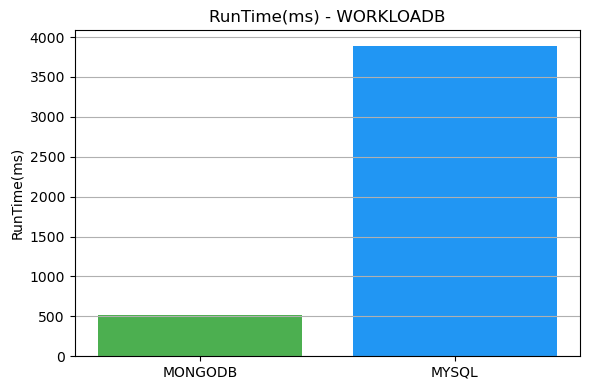

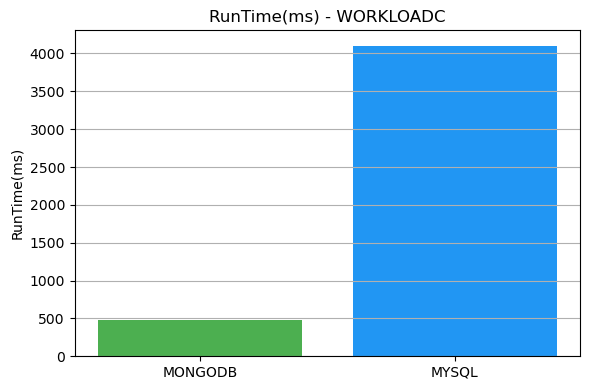

In [43]:
# Plot for each workload
for workload in workloads:
    for metric in metrics_to_extract.values():
        labels = []
        values = []
        for db in databases:
            val = results[workload][db].get(metric, None)
            if val is not None:
                labels.append(db.upper())
                values.append(val)
        
        if values:
            plt.figure(figsize=(6, 4))
            plt.bar(labels, values, color=['#4CAF50', '#2196F3'])
            plt.title(f"{metric} - {workload.upper()}")
            plt.ylabel(metric)
            plt.grid(True, axis='y')
            plt.tight_layout()
            plt.show()


### t-test 
A t-test was conducted to compare the performance of MongoDB and MySQL.

In [67]:
data_records = []
for workload in workloads:
    for db in databases:
        metrics = results[workload][db]
        if metrics:
            record = {
                'Workload': workload,
                'Database': db,
                'RunTime_ms': metrics.get('RunTime(ms)', None)
            }
            data_records.append(record)
df = pd.DataFrame(data_records)


In [68]:
df

,Workload,Database,RunTime_ms
0,workloada,mongodb,1833.0
1,workloada,mysql,4710.0
2,workloadb,mongodb,518.0
3,workloadb,mysql,3890.0
4,workloadc,mongodb,478.0
5,workloadc,mysql,4101.0


In [75]:
# Separate execution times
mongo_ycsb = df[df["Database"] == "mongodb"]["RunTime_ms"]
mysql_ycsb = df[df["Database"] == "mysql"]["RunTime_ms"]


In [76]:
# Perform t-test
t_stat, p_value = stats.ttest_ind(mongo_ycsb, mysql_ycsb, equal_var=False)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")


T-statistic: -6.4710765301405715
P-value: 0.006662995107848102


t-test result:

p-value is lower thar 0.05, rejecting the null hypothesis, suggesting that there is a statistically difference.

## Comparison Cassandra VS Spark SQL

### Query performance on tweets dataset

A comparison between Spark SQL and Cassandra was conducted. The experiment consisted in make 10 queries in each platform. These queries involved searching for a specific tweet in the tweets dataset, and search for a specific date in the tickers dataset. 


start connection

Option 1:

In [29]:
#start conecction from terminal
#pyspark --packages com.datastax.spark:spark-cassandra-connector_2.12:3.4.0


Option 2:

In [ ]:
# Start Spark Session
spark = SparkSession.builder \
    .appName("DatabaseComparison") \
    .config("spark.cassandra.connection.host", "your_cassandra_host") \
    .getOrCreate()


Checking conecction

In [5]:
spark.read.format("org.apache.spark.sql.cassandra").options(table="tweets", keyspace="stockks").load().show(5)


+------+----+------+--------------------+
|    id|date|ticker|               tweet|
+------+----+------+--------------------+
|103459|null|    BA|$BA With new mana...|
|108745|null|  TSLA|$TSLA its been a ...|
|102681|null|  TSLA|$TSLA Buuuuuurn b...|
|104691|null|  TSLA|$TSLA i short is ...|
|104019|null|  TSLA|$TSLA Bwahahahaha...|
+------+----+------+--------------------+
only showing top 5 rows



configure Cassandra and Spark SQL, searching for id = 103459, in tweets

In [141]:
# Cassandra query function
def query_cassandra():
    start = time.time()
    df = spark.read \
        .format("org.apache.spark.sql.cassandra") \
        .options(table="tweets", keyspace="stockks") \
        .load() \
        .filter("id = 103459") \
        .collect()
    end = time.time()
    return end - start, len(df)

In [142]:
# Spark SQL query function
def query_spark_sql():
    start = time.time()
    df = spark.sql("SELECT * FROM tweets WHERE id = 103459")
    results = df.collect()
    end = time.time()
    return end - start, len(results)

In [143]:
# Run Tests
results = []
for i in range(5):
    cass_time, cass_rows = query_cassandra()
    spark_time, spark_rows = query_spark_sql()
    results.append(("Cassandra", cass_time, cass_rows))
    results.append(("SparkSQL", spark_time, spark_rows))

Print Results

In [38]:
# print results
print("=== COMPARISON RESULTS ===")
for db, time_taken, row_count in results:
    print(f"Database: {db}, Time: {time_taken:.4f} sec, Rows Returned: {row_count}")

=== COMPARISON RESULTS ===
Database: Cassandra, Time: 0.6726 sec, Rows Returned: 1
Database: SparkSQL, Time: 0.1967 sec, Rows Returned: 1
Database: Cassandra, Time: 0.2859 sec, Rows Returned: 1
Database: SparkSQL, Time: 0.0931 sec, Rows Returned: 1
Database: Cassandra, Time: 0.6500 sec, Rows Returned: 1
Database: SparkSQL, Time: 0.1486 sec, Rows Returned: 1
Database: Cassandra, Time: 0.3637 sec, Rows Returned: 1
Database: SparkSQL, Time: 0.0847 sec, Rows Returned: 1
Database: Cassandra, Time: 0.3904 sec, Rows Returned: 1
Database: SparkSQL, Time: 0.1240 sec, Rows Returned: 1


In [40]:
i# Save results
df_tweet_results = pd.DataFrame(results, columns=["Database", "ExecutionTime", "RowCount"])
df_tweet_results.to_csv("casandra_sparksql_comparison.csv", index=False)


In [42]:
df_tweet_results

,Database,ExecutionTime,RowCount
0,Cassandra,0.672624,1
1,SparkSQL,0.196687,1
2,Cassandra,0.285866,1
3,SparkSQL,0.093124,1
4,Cassandra,0.650014,1
5,SparkSQL,0.148582,1
6,Cassandra,0.363732,1
7,SparkSQL,0.084652,1
8,Cassandra,0.390361,1
9,SparkSQL,0.123955,1


### Plot Individual Query Execution Time 

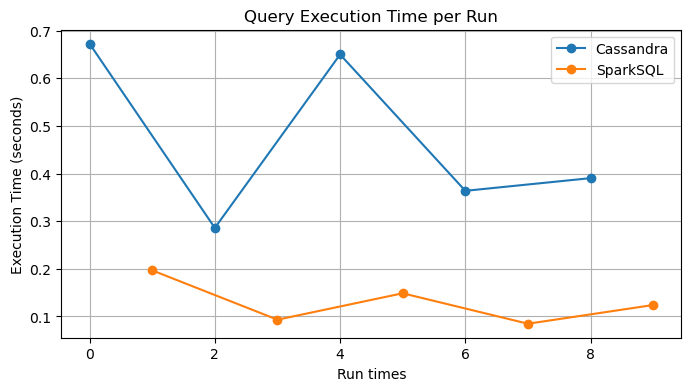

In [105]:
# Plot individual query times
plt.figure(figsize=(8,4))
for db in df_results['Database'].unique():
    subset = df_results[df_results['Database'] == db]
    plt.plot(subset.index, subset['ExecutionTime'], marker='o', label=db)

plt.title("Query Execution Time per Run")
plt.xlabel("Run times")
plt.ylabel("Execution Time (seconds)")
plt.legend()
plt.grid(True)
plt.show()


### Plot Average Query Execution Time

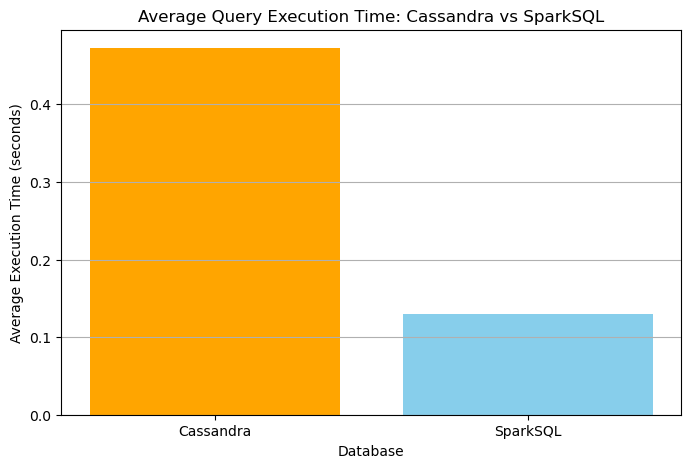

In [144]:

# Convert results into a DataFrame
df_results = pd.DataFrame(df_tweet_results, columns=["Database", "ExecutionTime", "RowCount"])

# Group by Database and calculate average time
df_avg = df_results.groupby("Database").mean().reset_index()

# Plot
plt.figure(figsize=(8, 5))
plt.bar(df_avg["Database"], df_avg["ExecutionTime"], color=["orange", "skyblue"])
plt.title("Average Query Execution Time: Cassandra vs SparkSQL")
plt.xlabel("Database")
plt.ylabel("Average Execution Time (seconds)")
plt.grid(axis='y')
plt.show()


In [145]:
df_avg

,Database,ExecutionTime,RowCount
0,Cassandra,0.472519,1.0
1,SparkSQL,0.129400,1.0


### t-test

A t-test was conducted in order to compare the performances between MySQL and Cassandra databases.

In [17]:
df_tweet_results = spark.read.csv("file:///home/hduser/Downloads/casandra_sparksql_comparison.csv", header=True, inferSchema=True)
df_tweet_results.show()

+---------+-------------------+--------+
| Database|      ExecutionTime|RowCount|
+---------+-------------------+--------+
|Cassandra| 0.6726241111755371|       1|
| SparkSQL| 0.1966867446899414|       1|
|Cassandra|0.28586578369140625|       1|
| SparkSQL| 0.0931243896484375|       1|
|Cassandra| 0.6500139236450195|       1|
| SparkSQL|0.14858222007751465|       1|
|Cassandra|0.36373209953308105|       1|
| SparkSQL|0.08465218544006348|       1|
|Cassandra|0.39036130905151367|       1|
| SparkSQL|0.12395548820495605|       1|
+---------+-------------------+--------+



In [22]:
# Convert to Pandas DataFrame
df_tweet_results = df_tweet_results.toPandas()

# Separate execution times
cassandra_tweet_t = df_tweet_results[df_tweet_results["Database"] == "Cassandra"]["ExecutionTime"]
sparksql_tweet_t = df_tweet_results[df_tweet_results["Database"] == "SparkSQL"]["ExecutionTime"]


In [23]:
# Perform t-test
t_stat, p_value = stats.ttest_ind(cassandra_tweet_t, sparksql_tweet_t, equal_var=False)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")


T-statistic: 4.20422032615119
P-value: 0.010494622003011642


The t-test results showed a p-value lower than 0.05, leading to the rejection of the null hypothesis. This suggests that there is a statistically significant difference in execution times.

## Query performance on Stock dataset

In [43]:
spark.read.format("org.apache.spark.sql.cassandra").options(table="tickers", keyspace="stockks").load().show(5)


+------+-------------------+------------------+------------------+------------------+------------------+--------+
|ticker|               date|             close|              high|               low|              open|  volume|
+------+-------------------+------------------+------------------+------------------+------------------+--------+
|  NVDA|2019-12-31 00:00:00| 58.82500076293945| 58.91999816894531|57.532501220703125|57.724998474121094|23100400|
|  NVDA|2020-01-02 00:00:00|59.977500915527344|59.977500915527344| 59.18000030517578|           59.6875|23753600|
|  NVDA|2020-01-03 00:00:00| 59.01750183105469| 59.45750045776367|58.525001525878906|58.775001525878906|20538400|
|  NVDA|2020-01-06 00:00:00| 59.26499938964844|59.317501068115234|57.817501068115234| 58.08000183105469|26263600|
|  NVDA|2020-01-07 00:00:00| 59.98249816894531|60.442501068115234| 59.09749984741211| 59.54999923706055|31485600|
+------+-------------------+------------------+------------------+------------------+---

configure Cassandra and Spark SQL, searching for date = 2019-12-31 00:00:00, in stock

In [109]:
# Cassandra query function
def query_cassandra():
    start = time.time()
    df = spark.read \
        .format("org.apache.spark.sql.cassandra") \
        .options(table="tickers", keyspace="stockks") \
        .load() \
        .filter("date = '2019-12-31 00:00:00'") \
        .collect()
    end = time.time()
    return end - start, len(df)

In [112]:
# Spark SQL query function
def query_spark_sql():
    start = time.time()
    df = spark.sql("SELECT * FROM ticker WHERE date = '2019-12-31 00:00:00'")
    results = df.collect()
    end = time.time()
    return end - start, len(results)

In [113]:
# Run Tests
results = []
for i in range(5):
    cass_time, cass_rows = query_cassandra()
    spark_time, spark_rows = query_spark_sql()
    results.append(("Cassandra", cass_time, cass_rows))
    results.append(("SparkSQL", spark_time, spark_rows))

#### Print Results

In [114]:
# print results
print("=== COMPARISON RESULTS ===")
for db, time_taken, row_count in results:
    print(f"Database: {db}, Time: {time_taken:.4f} sec, Rows Returned: {row_count}")

=== COMPARISON RESULTS ===
Database: Cassandra, Time: 0.5178 sec, Rows Returned: 5
Database: SparkSQL, Time: 0.1158 sec, Rows Returned: 5
Database: Cassandra, Time: 0.3187 sec, Rows Returned: 5
Database: SparkSQL, Time: 0.0889 sec, Rows Returned: 5
Database: Cassandra, Time: 0.3846 sec, Rows Returned: 5
Database: SparkSQL, Time: 0.0910 sec, Rows Returned: 5
Database: Cassandra, Time: 0.2609 sec, Rows Returned: 5
Database: SparkSQL, Time: 0.0993 sec, Rows Returned: 5
Database: Cassandra, Time: 0.5545 sec, Rows Returned: 5
Database: SparkSQL, Time: 0.1670 sec, Rows Returned: 5


In [115]:
# Save results
df_stock_results = pd.DataFrame(results, columns=["Database", "ExecutionTime", "RowCount"])
df_stock_results.to_csv("casandra_sparksql_comparison_stocks.csv", index=False)


In [116]:
df_stock_results

,Database,ExecutionTime,RowCount
0,Cassandra,0.517830,5
1,SparkSQL,0.115799,5
2,Cassandra,0.318652,5
3,SparkSQL,0.088877,5
4,Cassandra,0.384634,5
5,SparkSQL,0.090951,5
6,Cassandra,0.260924,5
7,SparkSQL,0.099329,5
8,Cassandra,0.554514,5
9,SparkSQL,0.166955,5


### Plot Individual Query Execution Time 

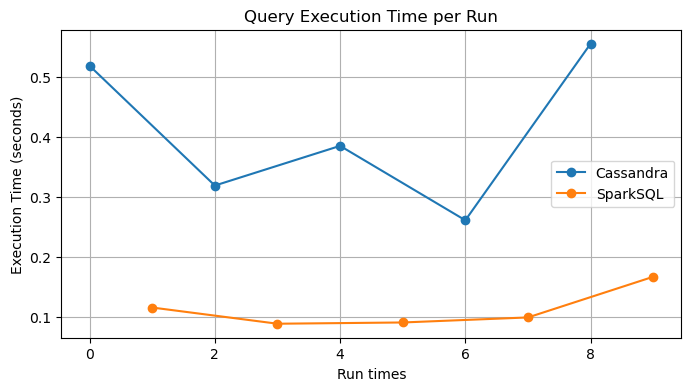

In [119]:
# Plot individual query times
plt.figure(figsize=(8,4))
for db in df_results['Database'].unique():
    subset = df_results[df_results['Database'] == db]
    plt.plot(subset.index, subset['ExecutionTime'], marker='o', label=db)

plt.title("Query Execution Time per Run")
plt.xlabel("Run times")
plt.ylabel("Execution Time (seconds)")
plt.legend()
plt.grid(True)
plt.show()


### Plot Average Query Execution Time

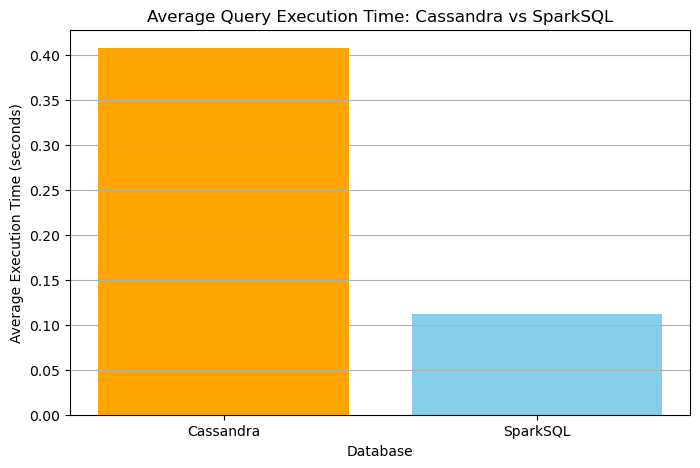

In [118]:

# Convert results into a DataFrame
df_results = pd.DataFrame(df_stock_results, columns=["Database", "ExecutionTime", "RowCount"])

# Group by Database and calculate average time
df_avg = df_results.groupby("Database").mean().reset_index()

# Plot
plt.figure(figsize=(8, 5))
plt.bar(df_avg["Database"], df_avg["ExecutionTime"], color=["orange", "skyblue"])
plt.title("Average Query Execution Time: Cassandra vs SparkSQL")
plt.xlabel("Database")
plt.ylabel("Average Execution Time (seconds)")
plt.grid(axis='y')
plt.show()


In [140]:
df_avg

,Database,ExecutionTime,RowCount
0,Cassandra,0.407311,5.0
1,SparkSQL,0.112382,5.0


### t-test

In [29]:
df_stock_results = spark.read.csv("file:///home/hduser/Downloads/casandra_sparksql_comparison_stocks.csv", header=True, inferSchema=True)
df_stock_results.show()

+---------+-------------------+--------+
| Database|      ExecutionTime|RowCount|
+---------+-------------------+--------+
|Cassandra| 0.5178303718566895|       5|
| SparkSQL| 0.1157989501953125|       5|
|Cassandra| 0.3186523914337158|       5|
| SparkSQL|0.08887720108032227|       5|
|Cassandra|0.38463354110717773|       5|
| SparkSQL|0.09095144271850586|       5|
|Cassandra| 0.2609243392944336|       5|
| SparkSQL|0.09932875633239746|       5|
|Cassandra|  0.554513692855835|       5|
| SparkSQL|0.16695547103881836|       5|
+---------+-------------------+--------+



In [30]:
# Convert to Pandas DataFrame
df_stock_results = df_stock_results.toPandas()

# Separate execution times
cassandra_stock_t = df_stock_results[df_stock_results["Database"] == "Cassandra"]["ExecutionTime"]
sparksql_stock_t = df_stock_results[df_stock_results["Database"] == "SparkSQL"]["ExecutionTime"]


In [31]:
# Perform t-test
t_stat, p_value = stats.ttest_ind(cassandra_stock_t, sparksql_stock_t, equal_var=False)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")


T-statistic: 5.063237727071219
P-value: 0.005144168354394637


the t-test results showed a p-value lower than 0.05, leading to the rejection of the null hypothesis.

## Sentiment Analysis with TextBlob

## AMZN Tweet Sentiment Analysis

In [12]:
amzn_tweet =spark.read.csv('/CA_2/tweet_amzn/part-00000-8a9cebd9-20c4-4237-b4ad-604b93ec28f4-c000.csv',header=True,inferSchema=True)

In [14]:
amzn_tweet.show(5)

+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100001|01/01/2020|  AMZN|$AMZN Dow futures...|
|100022|03/01/2020|  AMZN|$AMZN who ever sh...|
|100030|06/01/2020|  AMZN|$AMZN I hope we c...|
|100053|07/01/2020|  AMZN|$AMZN CONGRATS TO...|
|100096|09/01/2020|  AMZN|$AMZN Now it’s mo...|
+------+----------+------+--------------------+
only showing top 5 rows



In [21]:
# define a Pandas UDF that returns polarity score

@pandas_udf(DoubleType()) #usisng doubletype for numerical sentiment value
def textblob_polarity(tweets):
    return tweets.apply(lambda tweet: TextBlob(tweet).sentiment.polarity)

In [23]:
amzn_sentiment = amzn_tweet.withColumn("polarity_score", textblob_polarity(amzn_tweet["tweet"]))

amzn_sentiment.show(5)

+------+----------+------+--------------------+--------------+
|    id|      date|ticker|               tweet|polarity_score|
+------+----------+------+--------------------+--------------+
|100001|01/01/2020|  AMZN|$AMZN Dow futures...|           0.0|
|100022|03/01/2020|  AMZN|$AMZN who ever sh...|           0.0|
|100030|06/01/2020|  AMZN|$AMZN I hope we c...|           0.5|
|100053|07/01/2020|  AMZN|$AMZN CONGRATS TO...|         0.225|
|100096|09/01/2020|  AMZN|$AMZN Now it’s mo...|           0.0|
+------+----------+------+--------------------+--------------+
only showing top 5 rows



saving sentiment analysis in Hadoop

In [24]:
amzn_sentiment.write.csv("/CA_2/tweet_amzn/sentiment_amzn.csv", header=True, mode="overwrite")


## AAPL Tweet Sentiment Analysis

In [3]:
aapl_tweet =spark.read.csv('/CA_2/tweet_appl/part-00000-a8caab35-b45f-4a18-b8c9-61fcb33f6771-c000.csv',header=True,inferSchema=True)

In [30]:
aapl_tweet.show(5)

+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100003|01/01/2020|  AAPL|$AAPL We’ll been ...|
|100007|02/01/2020|  AAPL|$AAPL $300 calls ...|
|100008|02/01/2020|  AAPL|$AAPL Remember, i...|
|100009|02/01/2020|  AAPL|$AAPL called it, ...|
|100011|02/01/2020|  AAPL|Apple is taking t...|
+------+----------+------+--------------------+
only showing top 5 rows



In [4]:
# defining a Pandas UDF that returns polarity score

@pandas_udf(DoubleType())
def textblob_polarity(tweets):
    return tweets.apply(lambda tweet: TextBlob(tweet).sentiment.polarity)

In [5]:
aapl_sentiment = aapl_tweet.withColumn("polarity_score", textblob_polarity(aapl_tweet["tweet"]))

aapl_sentiment.show(5)

+------+----------+------+--------------------+-------------------+
|    id|      date|ticker|               tweet|     polarity_score|
+------+----------+------+--------------------+-------------------+
|100003|01/01/2020|  AAPL|$AAPL We’ll been ...|                0.0|
|100007|02/01/2020|  AAPL|$AAPL $300 calls ...|               0.25|
|100008|02/01/2020|  AAPL|$AAPL Remember, i...|0.14285714285714285|
|100009|02/01/2020|  AAPL|$AAPL called it, ...|                0.0|
|100011|02/01/2020|  AAPL|Apple is taking t...|                0.0|
+------+----------+------+--------------------+-------------------+
only showing top 5 rows



saving sentiment analysis in Hadoop

In [34]:
aapl_sentiment.write.csv("/CA_2/tweet_appl/sentiment_aapl", header=True, mode="overwrite")


#### Plot sentimental analysis by textblob

In [6]:

df_aapl_s = aapl_sentiment.withColumn(
    "polarity_score",
    when(aapl_sentiment["polarity_score"] > 0.1, "Positive")
    .when(aapl_sentiment["polarity_score"] < -0.1, "Negative")
    .otherwise("Neutral")
)


In [7]:
df_aapl_s.groupBy("polarity_score").count().show()

+--------------+-----+
|polarity_score|count|
+--------------+-----+
|       Neutral|  942|
|      Positive|  580|
|      Negative|  199|
+--------------+-----+



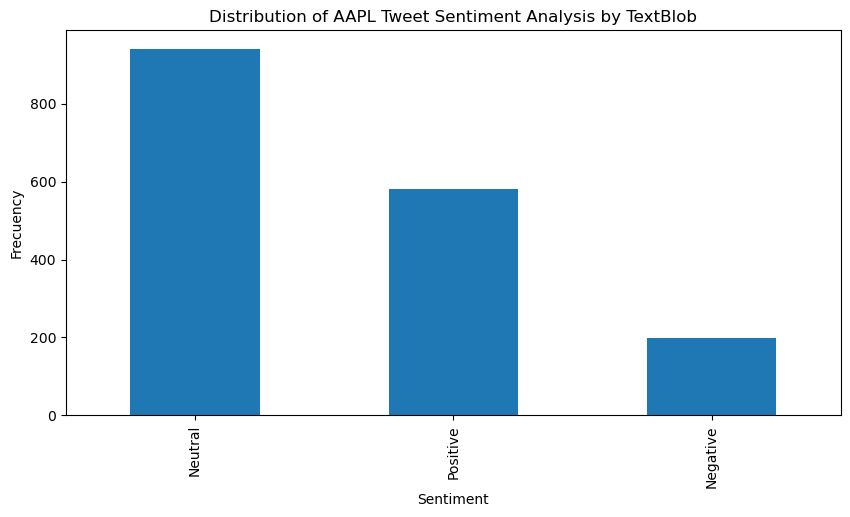

In [8]:
sentment_aapl_plot= df_aapl_s.select("polarity_score").toPandas()
sentment_aapl_plot["polarity_score"].value_counts().plot(kind="bar", figsize=(10,5))
plt.xlabel("Sentiment")
plt.ylabel("Frecuency")
plt.title("Distribution of AAPL Tweet Sentiment Analysis by TextBlob")
plt.show()

### Chi-Squared test Vader vs Textblob

Chi-Squared was applied to analyse statistically wether there are significant differences between the sentiment classifications (Positive, Neutral, Negative) produced by VADER and TextBlob on AAPL tweets.

In [11]:
# data from VADER and TextBlob

#Refer to  AAPL sentimental analysis Section in Advaced_data jupyter notebook
vader_counts = [918, 522, 280]      # [positive, neutral, negative]


textblob_counts = [942, 580, 199]   # [positive, neutral, negative]


In [12]:
# Create LabeledPoint instances
data = [
    LabeledPoint(0.0, Vectors.dense(vader_counts)),
    LabeledPoint(1.0, Vectors.dense(textblob_counts))
]

# Parallelize the data
vader_textb = sc.parallelize(data)

In [13]:
# Perform Chi-Squared test
chi_sq_results = Statistics.chiSqTest(vader_textb)

# Display the results
for i, result in enumerate(chi_sq_results):
    print(f"Feature {i}:")
    print(f"  p-value = {result.pValue}")
    print(f"  statistic = {result.statistic}")


Feature 0:
  p-value = 0.157299207050285
  statistic = 2.0
Feature 1:
  p-value = 0.157299207050285
  statistic = 2.0
Feature 2:
  p-value = 0.157299207050285
  statistic = 2.0


Observations: the p-value is greater than 0.05, we fail to reject the null hypothesis, indicating there are no statistical differences between features(positive, neutral, and negative).

## NFLX Tweet Sentiment Analysis

In [35]:
nflx_tweet =spark.read.csv('/CA_2/tweet_nflx/part-00000-54b85ada-405f-4b8e-aaed-2a35d7390e7d-c000.csv',header=True,inferSchema=True)

In [36]:
nflx_tweet.show(5)

+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100032|06/01/2020|  NFLX|$NFLX 🔥🔥🔥✈️ 33...|
|100118|10/01/2020|  NFLX|$NFLX Morningstar...|
|100237|18/01/2020|  NFLX|$NFLX 💵 booked a...|
|100254|22/01/2020|  NFLX|$NFLX love when t...|
|100278|22/01/2020|  NFLX|$NFLX  sooo if 36...|
+------+----------+------+--------------------+
only showing top 5 rows



In [31]:
# defining a Pandas UDF that returns polarity score

@pandas_udf(DoubleType())
def textblob_polarity(tweets):
    return tweets.apply(lambda tweet: TextBlob(tweet).sentiment.polarity)

In [37]:
nflx_sentiment = nflx_tweet.withColumn("polarity_score", textblob_polarity(nflx_tweet["tweet"]))

nflx_sentiment.show(5)

+------+----------+------+--------------------+-------------------+
|    id|      date|ticker|               tweet|     polarity_score|
+------+----------+------+--------------------+-------------------+
|100032|06/01/2020|  NFLX|$NFLX 🔥🔥🔥✈️ 33...|                0.0|
|100118|10/01/2020|  NFLX|$NFLX Morningstar...|                0.7|
|100237|18/01/2020|  NFLX|$NFLX 💵 booked a...|                0.0|
|100254|22/01/2020|  NFLX|$NFLX love when t...|               0.25|
|100278|22/01/2020|  NFLX|$NFLX  sooo if 36...|0.17045454545454544|
+------+----------+------+--------------------+-------------------+
only showing top 5 rows



saving sentiment analysis in Hadoop

In [38]:
nflx_sentiment.write.csv("/CA_2/tweet_nflx/sentiment_nflx", header=True, mode="overwrite")


## NVDA Tweet Sentiment Analysis

In [39]:
nvda_tweet =spark.read.csv('/CA_2/tweet_nvda/part-00000-e4c5831d-a122-4f7c-bf85-1f041e9d15d0-c000.csv',header=True,inferSchema=True)

In [40]:
nvda_tweet.show(5)

+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100014|03/01/2020|  NVDA|$NVDA This should...|
|100109|10/01/2020|  NVDA|$NVDA i love when...|
|100678|11/02/2020|  NVDA|$NVDA thoughts op...|
|100746|13/02/2020|  NVDA|$NVDA Easy money ...|
|100809|19/02/2020|  NVDA|$NVDA 👏👏💸💸💸👏👏|
+------+----------+------+--------------------+
only showing top 5 rows



In [31]:
# defining a Pandas UDF that returns polarity score

@pandas_udf(DoubleType())
def textblob_polarity(tweets):
    return tweets.apply(lambda tweet: TextBlob(tweet).sentiment.polarity)

In [41]:
nvda_sentiment = nvda_tweet.withColumn("polarity_score", textblob_polarity(nvda_tweet["tweet"]))

nvda_sentiment.show(5)

+------+----------+------+--------------------+--------------------+
|    id|      date|ticker|               tweet|      polarity_score|
+------+----------+------+--------------------+--------------------+
|100014|03/01/2020|  NVDA|$NVDA This should...|                -0.3|
|100109|10/01/2020|  NVDA|$NVDA i love when...| 0.39285714285714285|
|100678|11/02/2020|  NVDA|$NVDA thoughts op...|0.022222222222222227|
|100746|13/02/2020|  NVDA|$NVDA Easy money ...| 0.43333333333333335|
|100809|19/02/2020|  NVDA|$NVDA 👏👏💸💸💸👏👏|                 0.0|
+------+----------+------+--------------------+--------------------+
only showing top 5 rows



saving sentiment analysis in Hadoop

In [42]:
nvda_sentiment.write.csv("/CA_2/tweet_nvda/sentiment_nvda", header=True, mode="overwrite")


## TSLA Tweet Sentiment Analysis

In [43]:
tsla_tweet =spark.read.csv('/CA_2/tweet_tsla/part-00000-5f2fa4b8-d082-4f0d-ad16-54afeac7ac02-c000.csv',header=True,inferSchema=True)

In [44]:
tsla_tweet.show(5)

+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100002|01/01/2020|  TSLA|$TSLA Daddy's dri...|
|100004|01/01/2020|  TSLA|$TSLA happy new y...|
|100005|01/01/2020|  TSLA|"$TSLA haha just ...|
|100006|01/01/2020|  TSLA|$TSLA NOBODY: Gas...|
|100019|03/01/2020|  TSLA|$TSLA  I must ris...|
+------+----------+------+--------------------+
only showing top 5 rows



In [31]:
# defining a Pandas UDF that returns polarity score

@pandas_udf(DoubleType())
def textblob_polarity(tweets):
    return tweets.apply(lambda tweet: TextBlob(tweet).sentiment.polarity)

In [45]:
tsla_sentiment = tsla_tweet.withColumn("polarity_score", textblob_polarity(tsla_tweet["tweet"]))

tsla_sentiment.show(5)

+------+----------+------+--------------------+------------------+
|    id|      date|ticker|               tweet|    polarity_score|
+------+----------+------+--------------------+------------------+
|100002|01/01/2020|  TSLA|$TSLA Daddy's dri...|           0.15625|
|100004|01/01/2020|  TSLA|$TSLA happy new y...|0.4681818181818182|
|100005|01/01/2020|  TSLA|"$TSLA haha just ...|               0.5|
|100006|01/01/2020|  TSLA|$TSLA NOBODY: Gas...|              -0.2|
|100019|03/01/2020|  TSLA|$TSLA  I must ris...|               0.5|
+------+----------+------+--------------------+------------------+
only showing top 5 rows



saving sentiment analysis in Hadoop

In [46]:
tsla_sentiment.write.csv("/CA_2/tweet_tsla/sentiment_tsla", header=True, mode="overwrite")


## Big Data from Reddit by Spark

In this part of the project, post from Reddit with the word AAPL were obtained. Statistics and Sentiment analysis were applied.

### checking Reddit API by obtaining post

In [122]:
# Initialize Reddit API client
reddit = praw.Reddit(
    client_id="MywBP2lbjes12ZJ1Xp0xBw",                # Find from your Reddit account
    client_secret="nvVuk4o75GBVcvreqZQC01_Hm5D5oA",   # Create username and find your own client secret
    user_agent='BDSP2025:v1.0 (by /u/Icy_Geologist3136 )'           # Custom user agent with your Reddit username
                                                                     # BDSPDataCollector is the name provided by you
)

# Test: Fetch latest posts from a subreddit (e.g., "worldnews")
subreddit = reddit.subreddit("AAPL")
for post in subreddit.new(limit=10):
    print(f"Title: {post.title}")
    print(f"Score: {post.score}")
    print(f"Author: {post.author}")
    print(f"Created UTC: {post.created_utc}")
    print(f"Selftext: {post.selftext}")
    print("-" * 50)

Title: How bad can this get?
Score: 4
Author: Big_rizzy
Created UTC: 1746441124.0
Selftext: No more 30% on App Store subscriptions, no more Google search money, no horse in the AI game.

I’m very keen to hear any positive outlooks for the next few years if anyone has any?
--------------------------------------------------
Title: APPL analysis for 2025
Score: 19
Author: Ok-Bobcat4138
Created UTC: 1746321263.0
Selftext: Apple's recent 4% dividend increase signals a strong commitment to shareholder value, likely attracting renewed interest from long-term investors. The company's $100 billion stock buyback program, set to commence in 2025, should further bolster investor confidence, enhance share price stability, and support sustained demand for the stock.
To mitigate risks associated with tariffs and reduce reliance on China-centric production, Apple is strategically pivoting its manufacturing operations to countries like Vietnam and India. This diversification aims to alleviate cost pres

### Obtain and Save posts in a json file

In [109]:

# Initialize Reddit API client
reddit = praw.Reddit(
    client_id="MywBP2lbjes12ZJ1Xp0xBw",               
    client_secret="nvVuk4o75GBVcvreqZQC01_Hm5D5oA",  
    user_agent='BDSP2025:v1.0 (by /u/Icy_Geologist3136 )'    
                                                                    
    
)

# Fetch latest posts from the subreddit and store in a local file

def fetch_and_store_reddit_data(subreddit_name="AAPL"): #topic
    subreddit = reddit.subreddit(subreddit_name)
    posts = []
    for post in subreddit.new(limit=100):  # Limit to 100 posts
        post_data = {
            "id": post.id,
            "title": post.title,
            "author": post.author.name if post.author else None,
            "created_utc": post.created_utc,
            "selftext": post.selftext,
            "score": post.score,
            "comments": post.num_comments
            
        }
        posts.append(post_data)
        
    
    
    # Convert posts to JSON
    posts_json = json.dumps(posts, indent=4)
    
    # Define a fixed filename for overwriting
    local_filename = "/home/hduser/Desktop/aapl_posts.json"
    
    # Write to local file system (this will overwrite the file each time)
    with open(local_filename, 'w') as local_file:
     for post in posts:
        local_file.write(json.dumps(post) + "\n")
    


    print(f"Data written to local file: {local_filename}")

# Call the function to fetch and store Reddit data
fetch_and_store_reddit_data("aapl")

Data written to local file: /home/hduser/Desktop/aapl_posts.json


### Loading AAPL reddit posts

In [110]:
df = spark.read.schema(schema).json("file:///home/hduser/Desktop/aapl_posts.json")
df.show(5)


+-------+--------------+-------------+--------------------+-----+--------+
|     id|        author|  created_utc|            selftext|score|comments|
+-------+--------------+-------------+--------------------+-----+--------+
|1kf8blm|     Big_rizzy|1.746441124E9|No more 30% on Ap...|    3|      15|
|1ke850f| Ok-Bobcat4138|1.746321263E9|Apple's recent 4%...|   20|      18|
|1kd3pz7|    AAPL201620|1.746199504E9|Positives:\n\n* S...|   31|      17|
|1kcnjpo|theBigReturner|1.746144213E9|[https://www.yout...|    0|       3|
|1kclj0v|     W3Analyst|1.746138495E9|                    |    0|      14|
+-------+--------------+-------------+--------------------+-----+--------+
only showing top 5 rows



#### Checking schema

In [83]:
df.printSchema()


root
 |-- id: string (nullable = true)
 |-- author: string (nullable = true)
 |-- created_utc: string (nullable = true)
 |-- selftext: string (nullable = true)
 |-- score: integer (nullable = true)
 |-- comments: string (nullable = true)



#### Total Post

In [111]:
df.count()


100

#### Authors by post

In [112]:
df.groupBy("author").count().orderBy("count", ascending=False).show()


+--------------------+-----+
|              author|count|
+--------------------+-----+
|      theBigReturner|   31|
|     Jonathankoh1971|   18|
|          AAPL201620|    9|
|           W3Analyst|    4|
|Appropriate-Thanks10|    3|
|    IrishWhiskey1989|    3|
|        bostonmacosx|    2|
|       poorestprince|    2|
|    foreignfilmfiend|    1|
|         EpicFace500|    1|
|             ketgray|    1|
|  SupermarketGlobal5|    1|
|      Forsaken-Bag32|    1|
|        Passionjason|    1|
|             sbeau87|    1|
|   IllustratorNo8019|    1|
|           jessepole|    1|
|       Ok-Bobcat4138|    1|
|Chemical_Swimming140|    1|
|       Soft-Bike8417|    1|
+--------------------+-----+
only showing top 20 rows



### Reddit Post Sentiment Analysis 

In [113]:
def get_sentiment(text):
    if text:
        return TextBlob(text).sentiment.polarity
    return 0.0

# Register as UDF
sentiment_udf = udf(get_sentiment, FloatType())


In [114]:
df = df.withColumn("sentiment", sentiment_udf(df["selftext"]))


In [115]:
df.select("selftext", "sentiment").orderBy("sentiment", ascending=False).show(truncate=False)


+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Columns

In [116]:
print(df.columns)


['id', 'author', 'created_utc', 'selftext', 'score', 'comments', 'sentiment']


### Sort by More Positive Post

In [117]:
df.select("selftext", "sentiment") \
  .orderBy("sentiment", ascending=False) \
  .show(truncate=False)


+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### Sort by More Negative Post

In [118]:
df.select("selftext", "sentiment") \
  .orderBy("sentiment") \
  .show(truncate=False)


+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### Classify Posts by Sentiment

In [120]:

df = df.withColumn(
    "sentiment_label",
    when(df["sentiment"] > 0.1, "Positive")
    .when(df["sentiment"] < -0.1, "Negative")
    .otherwise("Neutral")
)


In [121]:
df.groupBy("sentiment_label").count().show()


+---------------+-----+
|sentiment_label|count|
+---------------+-----+
|        Neutral|   86|
|       Positive|   11|
|       Negative|    3|
+---------------+-----+



### Plot of AAPL Reddit Post

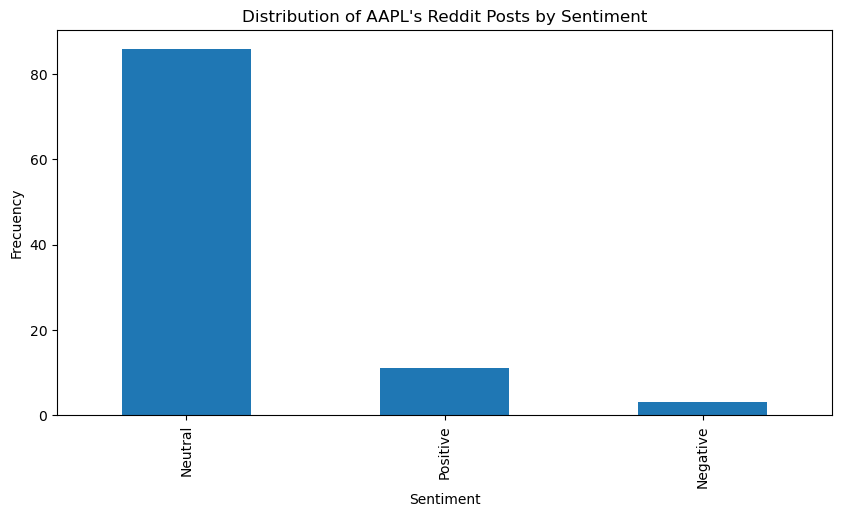

In [125]:
sentiment_p= df.select("sentiment_label").toPandas()
sentiment_p["sentiment_label"].value_counts().plot(kind="bar", figsize=(10,5))
plt.xlabel("Sentiment")
plt.ylabel("Frecuency")
plt.title("Distribution of AAPL's Reddit Posts by Sentiment")
plt.show()

## Streaming Data from Reddit by Kafka Producer

### Reddit to Kafka Producer

In [ ]:
# Set up Reddit API 
reddit = praw.Reddit(
    client_id="MywBP2lbjes12ZJ1Xp0xBw",
    client_secret="nvVuk4o75GBVcvreqZQC01_Hm5D5oA",
    user_agent='BDSP2025:v1.0 (by /u/Icy_Geologist3136 )',
 
)


# Set up Kafka producer
producer = KafkaProducer(
    bootstrap_servers='localhost:9092',
    value_serializer=lambda v: json.dumps(v).encode('utf-8')
)

# Choose subreddit and send posts
subreddit = reddit.subreddit('AAPL') 

print("Streaming posts from r/technology to Kafka...")
for post in subreddit.stream.submissions():
    data = {
        'title': post.title,
        'url': post.url,
        'score': post.score,
        'created': post.created_utc
    }
    producer.send('reddit-topic', data)
    print(f"Sent: {data['title']}")
    time.sleep(1)  # avoid overloading


Streaming posts from r/technology to Kafka...
Sent: Upvote if you ADDED Into AAPL. I think this is just a DIP OPPORTUNTIY. (LONGTERM FTW)
Sent: LATEST Analysis on AAPL STOCK (Buy the dip)
Sent: Went all in at 213 today
Sent: What’s up Apple fan bois! Who’s trading Apple options?
Sent: Apple’s Crisis in China: What Went Wrong for the Tech Giant?
Sent: AAPL & Magnificent 7 Stock Analysis - Which is a Buy or Sell?
Sent: Apple’s Worldwide Developers Conference returns the week of June 9
Sent: AAPL Latest Analysis for April 2025
Sent: Why does Apple's stock price keep rising and never fall below $3 trillion in total market value?
Sent: How do you guys feel about Tom Lee? Thinks we get a Full V Sharp Recovery after April 2nd?
Sent: AAPL Latest Analysis for April 2025
Sent: Apple Stock:  Will it continue to outperform the market?
Sent: Buying long calls on AAPL.
Sent: What happened one day last summer. It’s gonna be a very choppy ride. Gotta pick your moments and timing is Key!!
Sent: Had a t

#### Screenshot of Kafka

terminal code for consumer:

$ bin/kafka-console-consumer.sh --topic reddit-topic --from-beginning --bootstrap-server localhost:9092

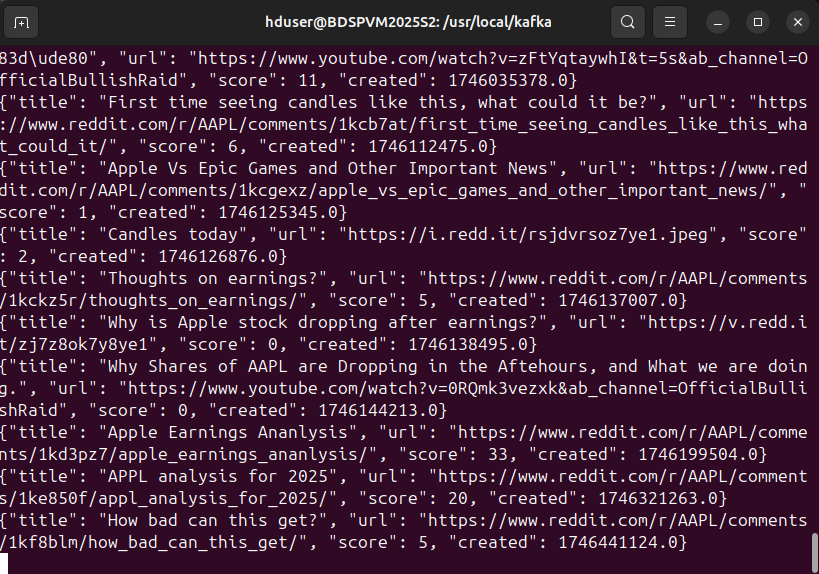

In [27]:
tweet_amzn = tweet.filter(col("ticker").isin('AMZN'))

tweet_amzn.show(5)

+------+----------+------+--------------------+
|    id|      date|ticker|               tweet|
+------+----------+------+--------------------+
|100001|01/01/2020|  AMZN|$AMZN Dow futures...|
|100022|03/01/2020|  AMZN|$AMZN who ever sh...|
|100030|06/01/2020|  AMZN|$AMZN I hope we c...|
|100053|07/01/2020|  AMZN|$AMZN CONGRATS TO...|
|100096|09/01/2020|  AMZN|$AMZN Now it’s mo...|
+------+----------+------+--------------------+
only showing top 5 rows

